#Study 2: High Population, Low Emissions

Which countries have high population but low per capita CO₂ emissions in the most recent years

**Criteria**

    High Population: Countries with population in the top 20.

    Low Emissions per Capita: Filter for countries whose co2 (per capita emissions) is below the global median.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from modules.data_loader import DataLoader

## Load Preprocessed Data
We load 4 databases and merge into a single DataFrame with the following columns:
 `Continent`, `Country`, `year`, `co2`, `gdp`, `population`, `total_co2`, `total_gdp`

In [2]:
# Load the preprocessed CSV 
loader = DataLoader()            # Create an instance of the DataLoader class
data = loader.load_and_prepare_data()  # Call the method to load and clean the data
data.head()

,Continent,Country,year,co2,gdp,population,total_co2,total_gdp
0,Africa,Algeria,1800,0.0,763.0,2500000.0,0.0,1.907500e+09
1,Africa,Algeria,1801,0.0,764.0,2510000.0,0.0,1.917640e+09
2,Africa,Algeria,1802,0.0,765.0,2520000.0,0.0,1.927800e+09
3,Africa,Algeria,1803,0.0,766.0,2530000.0,0.0,1.937980e+09
4,Africa,Algeria,1804,0.0,767.0,2540000.0,0.0,1.948180e+09


## Scatter Plot: Population vs CO₂ per Capita (2020)
Visualizing the correlation between population and CO₂ emissions for the year 2020.

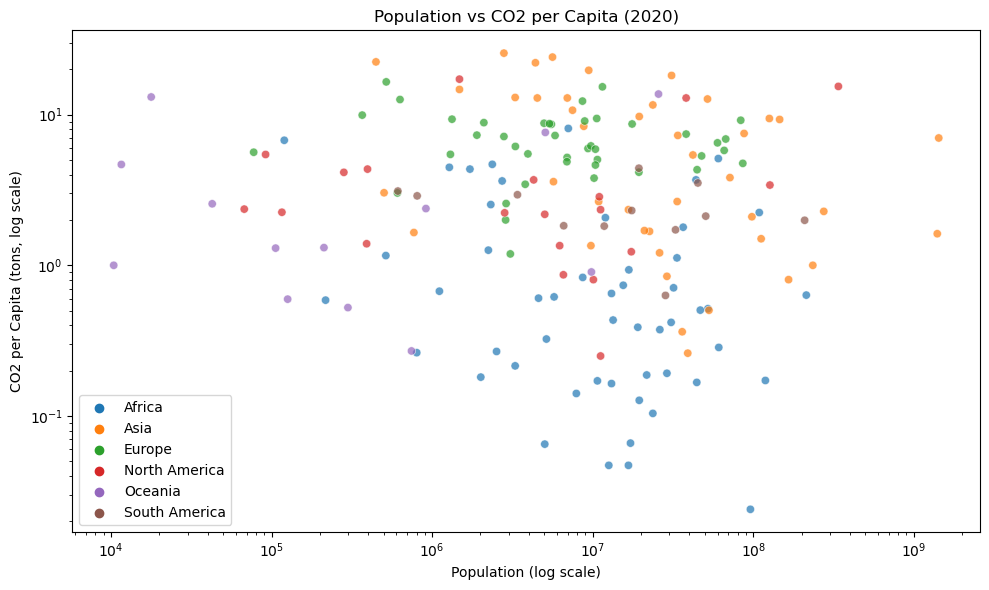

In [4]:
year_filter = 2020
scatter_data = data[data["year"] == year_filter]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_data, x="population", y="co2", hue="Continent", alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.title(f"Population vs CO2 per Capita ({year_filter})")
plt.xlabel("Population (log scale)")
plt.ylabel("CO2 per Capita (tons, log scale)")
plt.legend()
plt.tight_layout()
plt.show()

No strong positive or negative linear correlation between population and CO2 per capita across all countries was observed. 

The points are widely scattered, indicating that a country's population size alone doesn't directly corrolate with its CO2 per capita emissions.


## Top 10 population with low emissions (< median)

### Bar chart

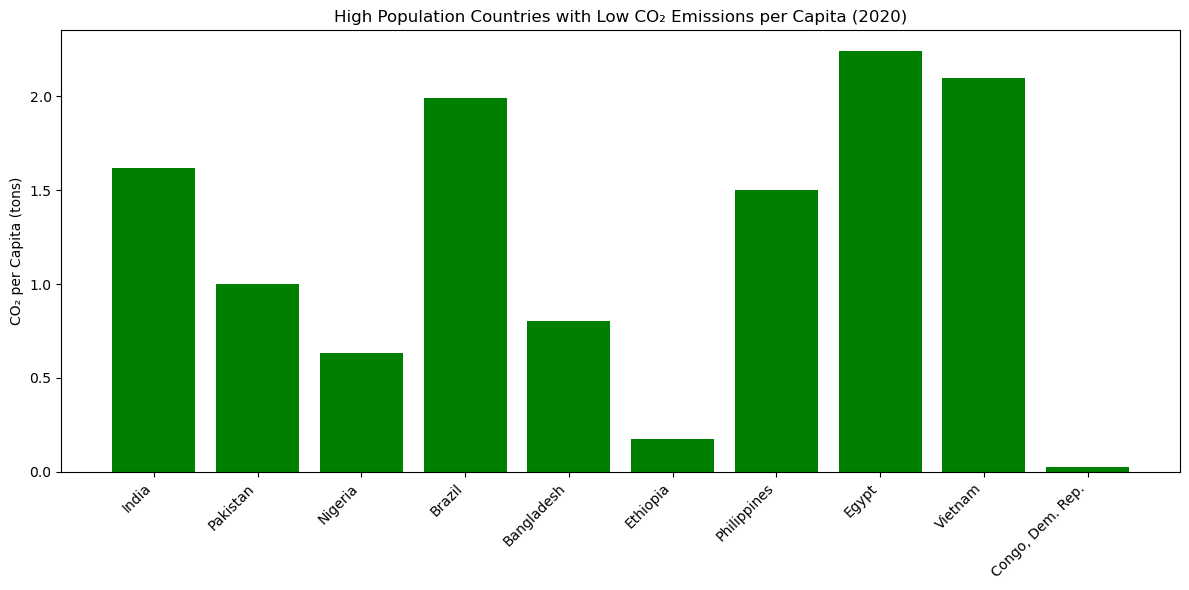

In [19]:
# Get top 20 countries by population
top_pop = scatter_data.sort_values(by='population', ascending=False).head(20)

# Filter for low per capita CO2 emissions (< median)
low_emissions = top_pop[top_pop['co2'] < top_pop['co2'].median()]
low_emissions.head(20)
# Display results
low_emissions_sorted = low_emissions.sort_values(by='population', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(low_emissions_sorted['Country'], low_emissions_sorted['co2'], color='green')
ax.set_ylabel('CO₂ per Capita (tons)')
ax.set_title('High Population Countries with Low CO₂ Emissions per Capita (2020)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




### Bubble chart

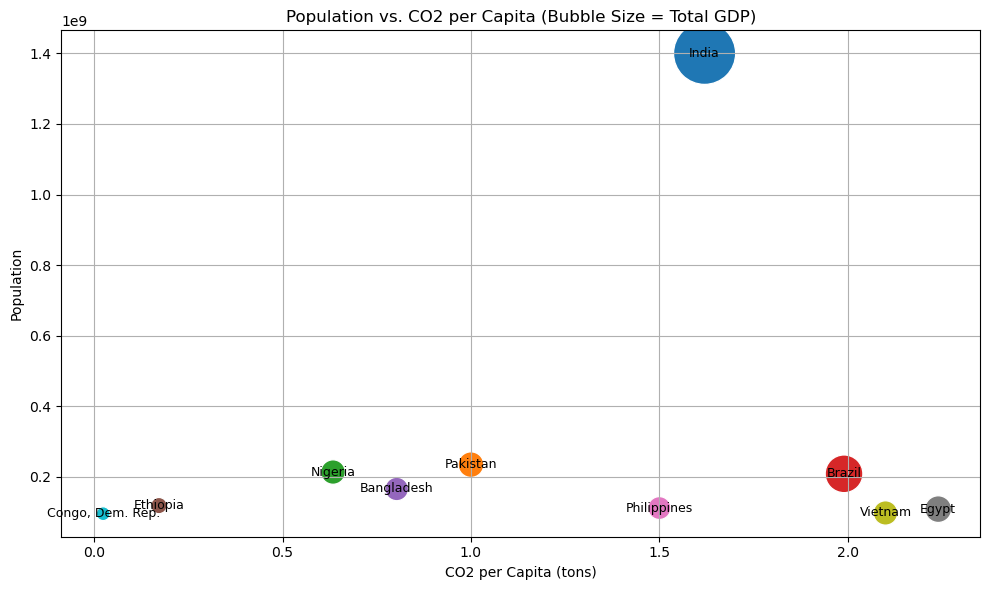

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=low_emissions_sorted,
    x='co2',
    y='population',
    size='total_gdp',
    hue='Country',
    legend=False,
    sizes=(100, 2000)
)

# Add country names to each point
for i in range(len(low_emissions_sorted)):
    row = low_emissions_sorted.iloc[i]
    plt.text(
        row['co2'],
        row['population'],
        row['Country'],
        fontsize=9,
        ha='center',
        va='center'
    )

plt.title('Population vs. CO2 per Capita (Bubble Size = Total GDP)')
plt.xlabel('CO2 per Capita (tons)')
plt.ylabel('Population')
plt.grid(True)
plt.tight_layout()
plt.show()

## Correlation Analysis
Compute Pearson correlation between population and CO₂ per capita for all countries in each year.

c:\Users\Behzad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Behzad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


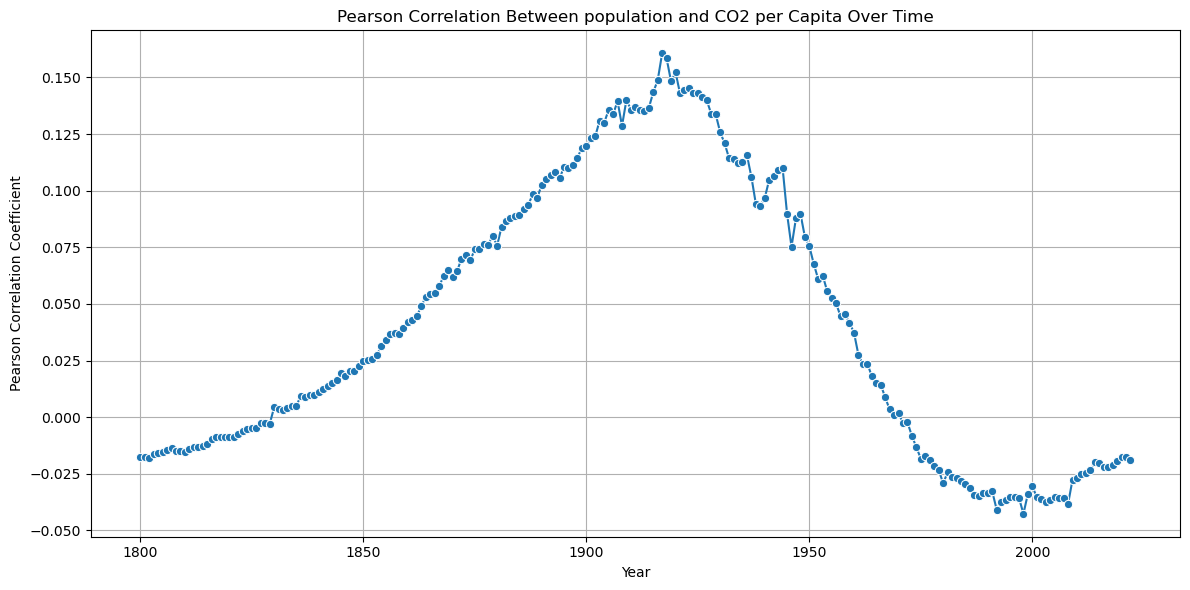

In [33]:
# Calculate Pearson correlation between population and CO₂ per capita for each year
correlation_by_year = data.groupby("year").apply(
    lambda group: group["population"].corr(group["co2"])
).reset_index(name="pearson_correlation")

# Plot the correlation trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=correlation_by_year, x="year", y="pearson_correlation", marker="o")
plt.title("Pearson Correlation Between population and CO2 per Capita Over Time")
plt.xlabel("Year")
plt.ylabel("Pearson Correlation Coefficient")
plt.grid(True)
plt.tight_layout()
plt.show()

The correlation coefficient is close to 0 especially in recennt decades. This implies that there is no consistent linear relationship between a country's population size and its per capita CO₂ emissions.